
# Notebook 5 — Evaluación de Métricas del Sistema

Este notebook evalúa el desempeño del sistema de comprensión automática de documentos científicos.

## Métricas implementadas

### OCR
- CER (Character Error Rate)
- WER (Word Error Rate)

### Resumen científico
- ROUGE-1
- ROUGE-L
- BERTScore

---

## Comparaciones

### OCR
- OCR original
- OCR corregido por Gemini

### Resúmenes
- Resumen generado
- Abstract real del paper

---

## Objetivo

Medir el impacto real de:
- la corrección contextual con LLM,
- la integración multimodal,
- y la síntesis científica automática.


In [21]:
"""
# ==========================================
# INSTALACIÓN DE DEPENDENCIAS
# ==========================================

# Ejecutar solo una vez

!pip install jiwer rouge-score bert-score -q
"""

'\n# ==========================================\n# INSTALACIÓN DE DEPENDENCIAS\n# ==========================================\n\n# Ejecutar solo una vez\n\n!pip install jiwer rouge-score bert-score -q\n'

In [22]:

# ==========================================
# IMPORTS
# ==========================================

from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

from jiwer import wer, cer
from rouge_score import rouge_scorer
from bert_score import score as bertscore



# Configuración de rutas

Ajusta las rutas según tu estructura actual del proyecto.


In [23]:

from pathlib import Path
from typing import Optional

# ==========================================
# PROJECT ROOT
# ==========================================

def find_project_root(start: Optional[Path] = None) -> Path:

    start = (start or Path.cwd()).resolve()

    for base in [start, *start.parents]:

        markers = [
            ("data", "notebooks"),
            ("src", "data"),
            ("pyproject.toml",),
            ("requirements.txt",),
        ]

        if any(all((base / m).exists() for m in group) for group in markers):
            return base

    return start


PROJECT_ROOT = find_project_root()

print("PROJECT_ROOT:", PROJECT_ROOT)

# ==========================================
# RUN CONFIG
# ==========================================

RUN_NAME = "paper_run_001"

RUN_DIR = PROJECT_ROOT / "data" / "outputs" / RUN_NAME

print("RUN_DIR:", RUN_DIR)

# ==========================================
# INPUTS
# ==========================================

OCR_ORIGINAL_DIR = RUN_DIR / "09_ocr_txt"

LLM_DIR = RUN_DIR / "40_llm"

CORRECTED_TEXT_DIR = LLM_DIR / "markdown"

SUMMARIES_DIR = LLM_DIR / "markdown"

GROUND_TRUTH_DIR = (
    PROJECT_ROOT
    / "data"
    / "ground_truth"
)

print("OCR_ORIGINAL_DIR:", OCR_ORIGINAL_DIR)
print("CORRECTED_TEXT_DIR:", CORRECTED_TEXT_DIR)
print("SUMMARIES_DIR:", SUMMARIES_DIR)
print("GROUND_TRUTH_DIR:", GROUND_TRUTH_DIR)

# ==========================================
# OUTPUT DIRECTORIES
# ==========================================

OUTPUT_DIRS = {

    "root":
        RUN_DIR / "50_metrics",

    "csv":
        RUN_DIR / "50_metrics" / "csv",

    "plots":
        RUN_DIR / "50_metrics" / "plots",

    "debug":
        RUN_DIR / "50_metrics" / "debug",
}

# ==========================================
# CREATE OUTPUT DIRECTORIES
# ==========================================

for path in OUTPUT_DIRS.values():
    path.mkdir(parents=True, exist_ok=True)

print("Directorios creados correctamente")


PROJECT_ROOT: C:\Users\user\proyectos\vision-docs
RUN_DIR: C:\Users\user\proyectos\vision-docs\data\outputs\paper_run_001
OCR_ORIGINAL_DIR: C:\Users\user\proyectos\vision-docs\data\outputs\paper_run_001\09_ocr_txt
CORRECTED_TEXT_DIR: C:\Users\user\proyectos\vision-docs\data\outputs\paper_run_001\40_llm\markdown
SUMMARIES_DIR: C:\Users\user\proyectos\vision-docs\data\outputs\paper_run_001\40_llm\markdown
GROUND_TRUTH_DIR: C:\Users\user\proyectos\vision-docs\data\ground_truth
Directorios creados correctamente



# Funciones auxiliares


In [24]:

# ==========================================
# FUNCIONES AUXILIARES
# ==========================================

def load_text(path):
    with open(path, "r", encoding="utf-8") as f:
        return f.read()


def compute_ocr_metrics(gt_text, pred_text):
    return {
        "WER": wer(gt_text, pred_text),
        "CER": cer(gt_text, pred_text)
    }


def compute_rouge(reference, generated):
    scorer = rouge_scorer.RougeScorer(
        ['rouge1', 'rougeL'],
        use_stemmer=True
    )

    scores = scorer.score(reference, generated)

    return {
        "ROUGE-1": scores["rouge1"].fmeasure,
        "ROUGE-L": scores["rougeL"].fmeasure
    }


def compute_bertscore(reference, generated):
    P, R, F1 = bertscore(
        [generated],
        [reference],
        lang="en"
    )

    return {
        "BERTScore_F1": float(F1.mean())
    }



# Evaluación OCR

Comparación:
- OCR original
- OCR corregido por Gemini


In [25]:

# ==========================================
# EVALUACIÓN OCR / CORRECCIÓN LLM
# ==========================================

ocr_results = []

# ==========================================
# INPUT FILES
# ==========================================

MULTIMODAL_FILE = (
    RUN_DIR
    / "30_multimodal"
    / "markdown"
    / "document_multimodal.md"
)

CORRECTED_FILE = (
    RUN_DIR
    / "40_llm"
    / "markdown"
    / "corrected_document.md"
)

print("MULTIMODAL_FILE:", MULTIMODAL_FILE)
print("CORRECTED_FILE:", CORRECTED_FILE)

# ==========================================
# LOAD TEXTS
# ==========================================

original_text = load_text(MULTIMODAL_FILE)

corrected_text = load_text(CORRECTED_FILE)

# ==========================================
# MÉTRICAS
# ==========================================

metrics = compute_ocr_metrics(
    original_text,
    corrected_text
)

# ==========================================
# SAVE RESULTS
# ==========================================

ocr_results.append({

    "WER":
        metrics["WER"],

    "CER":
        metrics["CER"]
})

ocr_df = pd.DataFrame(ocr_results)

ocr_df


MULTIMODAL_FILE: C:\Users\user\proyectos\vision-docs\data\outputs\paper_run_001\30_multimodal\markdown\document_multimodal.md
CORRECTED_FILE: C:\Users\user\proyectos\vision-docs\data\outputs\paper_run_001\40_llm\markdown\corrected_document.md


,WER,CER
0,0.385423,0.117204



# Resultados promedio OCR


In [26]:

# ==========================================
# PROMEDIOS OCR
# ==========================================

ocr_summary = ocr_df.mean(numeric_only=True)

print(ocr_summary)


WER    0.385423
CER    0.117204
dtype: float64


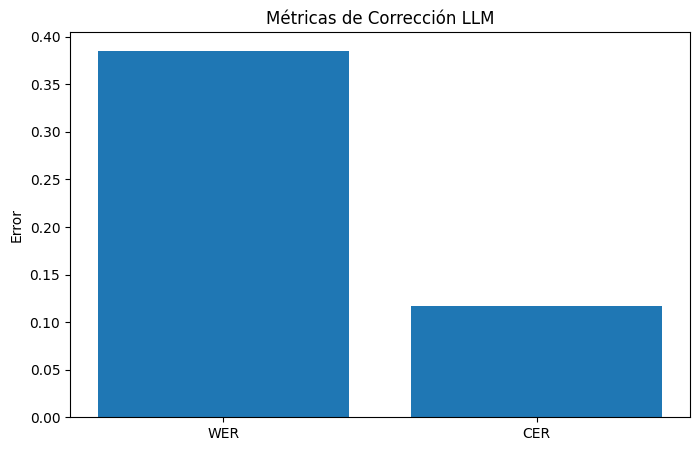

In [27]:
# ==========================================
# VISUALIZACIÓN OCR
# ==========================================

plt.figure(figsize=(8,5))

metrics_names = ["WER", "CER"]

metrics_values = [
    ocr_df["WER"].iloc[0],
    ocr_df["CER"].iloc[0]
]

plt.bar(
    metrics_names,
    metrics_values
)

plt.title("Métricas de Corrección LLM")
plt.ylabel("Error")

plt.show()


# Evaluación de Resúmenes

Comparación:
- resumen generado,
- abstract real.


In [28]:

# ==========================================
# EVALUACIÓN OCR / CORRECCIÓN LLM
# ==========================================

ocr_results = []

# ==========================================
# INPUT FILES
# ==========================================

MULTIMODAL_FILE = (
    RUN_DIR
    / "30_multimodal"
    / "markdown"
    / "document_multimodal.md"
)

CORRECTED_FILE = (
    RUN_DIR
    / "40_llm"
    / "markdown"
    / "corrected_document.md"
)

print("MULTIMODAL_FILE:", MULTIMODAL_FILE)
print("CORRECTED_FILE:", CORRECTED_FILE)

# ==========================================
# LOAD TEXTS
# ==========================================

original_text = load_text(MULTIMODAL_FILE)

corrected_text = load_text(CORRECTED_FILE)

# ==========================================
# MÉTRICAS
# ==========================================

metrics = compute_ocr_metrics(
    original_text,
    corrected_text
)

# ==========================================
# SAVE RESULTS
# ==========================================

ocr_results.append({

    "WER":
        metrics["WER"],

    "CER":
        metrics["CER"]
})

ocr_df = pd.DataFrame(ocr_results)

ocr_df


MULTIMODAL_FILE: C:\Users\user\proyectos\vision-docs\data\outputs\paper_run_001\30_multimodal\markdown\document_multimodal.md
CORRECTED_FILE: C:\Users\user\proyectos\vision-docs\data\outputs\paper_run_001\40_llm\markdown\corrected_document.md


,WER,CER
0,0.385423,0.117204



# Resultados promedio de resúmenes


In [29]:

print("No hay evaluación de resúmenes configurada actualmente.")


No hay evaluación de resúmenes configurada actualmente.


In [30]:

print("No hay gráficas de resumen disponibles actualmente.")


No hay gráficas de resumen disponibles actualmente.



# Métricas adicionales

Se agregan métricas complementarias para evaluar:

- compresión/reorganización del documento,
- reducción de ruido OCR,
- preservación estructural del markdown.


In [31]:

# ==========================================
# MÉTRICA 1 — COMPRESSION RATIO
# ==========================================

compression_ratio = (
    len(corrected_text) / len(original_text)
)

print("Compression Ratio:", compression_ratio)

# ==========================================
# MÉTRICA 2 — OCR NOISE REDUCTION
# ==========================================

import re

def count_noise(text):

    pattern = r"[^a-zA-Z0-9\s\.,;:\-\(\)#\|]"

    noise = re.findall(pattern, text)

    return len(noise)

noise_original = count_noise(original_text)

noise_corrected = count_noise(corrected_text)

noise_reduction = (
    noise_original - noise_corrected
)

print("Noise Original:", noise_original)
print("Noise Corrected:", noise_corrected)
print("Noise Reduction:", noise_reduction)

# ==========================================
# MÉTRICA 3 — STRUCTURAL PRESERVATION
# ==========================================

original_headers = original_text.count("#")
corrected_headers = corrected_text.count("#")

original_tables = original_text.count("|")
corrected_tables = corrected_text.count("|")

header_preservation = (
    corrected_headers / max(original_headers, 1)
)

table_preservation = (
    corrected_tables / max(original_tables, 1)
)

print("Header Preservation:", header_preservation)
print("Table Preservation:", table_preservation)

# ==========================================
# SAVE EXTRA METRICS
# ==========================================

ocr_df["Compression_Ratio"] = compression_ratio

ocr_df["Noise_Original"] = noise_original
ocr_df["Noise_Corrected"] = noise_corrected
ocr_df["Noise_Reduction"] = noise_reduction

ocr_df["Header_Preservation"] = header_preservation
ocr_df["Table_Preservation"] = table_preservation

ocr_df


Compression Ratio: 0.9326876900912437
Noise Original: 96
Noise Corrected: 233
Noise Reduction: -137
Header Preservation: 1.0
Table Preservation: 0.6666666666666666


,WER,CER,Compression_Ratio,Noise_Original,Noise_Corrected,Noise_Reduction,Header_Preservation,Table_Preservation
0,0.385423,0.117204,0.932688,96,233,-137,1.0,0.666667



# Exportación de resultados


In [32]:
# ==========================================
# EXPORTACIÓN
# ==========================================

ocr_csv = OUTPUT_DIRS["csv"] / "ocr_metrics.csv"

ocr_df.to_csv(
    ocr_csv,
    index=False
)

print("OCR metrics guardado en:")
print(ocr_csv)

OCR metrics guardado en:
C:\Users\user\proyectos\vision-docs\data\outputs\paper_run_001\50_metrics\csv\ocr_metrics.csv



# Conclusiones

Este notebook permite:

- evaluar cuantitativamente el impacto del LLM,
- medir mejoras en OCR,
- evaluar calidad de resúmenes científicos,
- comparar distintas versiones del pipeline,
- y generar resultados reproducibles para el proyecto académico.
